# State-based RSSM + VLM scorer для MiniGrid

В этой версии world model работает не с RGB-кадрами, а с компактным состоянием среды:

- `agent_x`
- `agent_y`
- `agent_dir`
- `wall_map`
- `goal_map`

RGB используется только для визуальной проверки и VLM-scoring: imagined states из RSSM
рендерятся обратно через MiniGrid.

In [64]:
import os
import random
from collections import defaultdict, deque

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import minigrid
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from minigrid.core.actions import Actions
from minigrid.core.constants import DIR_TO_VEC
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm, trange
import imageio.v2 as imageio
from IPython.display import Image, display, Markdown


PROJECT_DIR = os.path.expanduser("~/Documents/Tbank")
DATA_DIR = os.path.join(PROJECT_DIR, "data")

STATE_DATA_PATH = os.path.join(DATA_DIR, "minigrid_crossing_state_mixed.npz")
STATE_MODEL_PATH = os.path.join(PROJECT_DIR, "state_rssm_world_model_best.pt")

ENV_NAME = "MiniGrid-SimpleCrossingS9N2-v0"


device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

pin_memory = device.type == "cuda"

print("device:", device)
print("state dataset:", STATE_DATA_PATH)
print("model path:", STATE_MODEL_PATH)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


device: mps
state dataset: /Users/roman666/Documents/Tbank/data/minigrid_crossing_state_mixed.npz
model path: /Users/roman666/Documents/Tbank/state_rssm_world_model_best.pt


## 1. Среда и компактное state-представление

In [65]:
def extract_minigrid_state(env):
    """
    Достает минимальный state из MiniGrid.

    wall_map и goal_map имеют форму [height, width].
    Индексация карты: map[y, x].
    """
    env_u = env.unwrapped

    width = int(env_u.width)
    height = int(env_u.height)

    wall_map = np.zeros((height, width), dtype=np.uint8)
    goal_map = np.zeros((height, width), dtype=np.uint8)

    for x in range(width):
        for y in range(height):
            cell = env_u.grid.get(x, y)

            if cell is None:
                continue

            if cell.type == "wall":
                wall_map[y, x] = 1
            elif cell.type == "goal":
                goal_map[y, x] = 1

    agent_x, agent_y = env_u.agent_pos

    return {
        "agent_x": int(agent_x),
        "agent_y": int(agent_y),
        "agent_dir": int(env_u.agent_dir),
        "wall_map": wall_map,
        "goal_map": goal_map,
    }


def build_grid_from_maps(wall_map, goal_map):
    wall_map = np.asarray(wall_map)
    goal_map = np.asarray(goal_map)

    height, width = wall_map.shape
    grid = Grid(width, height)

    for y in range(height):
        for x in range(width):
            if wall_map[y, x] > 0:
                grid.set(x, y, Wall())
            elif goal_map[y, x] > 0:
                grid.set(x, y, Goal())

    return grid


def render_minigrid_state(
    wall_map,
    goal_map,
    agent_x,
    agent_y,
    agent_dir,
    env_name=ENV_NAME,
):
    """
    Рендерит state через саму MiniGrid-среду.

    Это не используется в обучении world model, только для визуальной проверки
    и будущего VLM scoring по imagined future frames.
    """
    env = gym.make(env_name, render_mode="rgb_array")
    env.reset(seed=0)

    env_u = env.unwrapped
    env_u.grid = build_grid_from_maps(wall_map, goal_map)
    env_u.agent_pos = np.array([int(agent_x), int(agent_y)])
    env_u.agent_dir = int(agent_dir)

    frame = env.render()
    env.close()

    return frame


## 2. Сбор нового state-датасета

Старые frame-datasets здесь не используются. Ниже собирается новый датасет, где каждый эпизод
хранит последовательность дискретных состояний и статические карты стен/цели.

In [66]:
# Алгоритм нахождения оптимального пути в ширину

def find_goal_pos(env):
    env_u = env.unwrapped

    for x in range(env_u.width):
        for y in range(env_u.height):
            cell = env_u.grid.get(x, y)

            if cell is not None and cell.type == "goal":
                return (x, y)

    raise RuntimeError("Goal not found in grid")


def can_move_to(env, pos):
    env_u = env.unwrapped
    x, y = pos

    if x < 0 or x >= env_u.width or y < 0 or y >= env_u.height:
        return False

    cell = env_u.grid.get(x, y)

    # None means empty cell
    if cell is None:
        return True

    return cell.can_overlap()


def shortest_path_actions(env):
    env_u = env.unwrapped

    start_pos = tuple(env_u.agent_pos)
    start_dir = int(env_u.agent_dir)
    goal_pos = find_goal_pos(env)

    start_state = (start_pos[0], start_pos[1], start_dir)

    queue = deque([start_state])
    parent = {start_state: None}
    parent_action = {}

    while queue:
        x, y, direction = queue.popleft()

        if (x, y) == goal_pos:
            actions = []
            state = (x, y, direction)

            while parent[state] is not None:
                actions.append(parent_action[state])
                state = parent[state]

            actions.reverse()
            return actions

        # action: left
        new_dir = (direction - 1) % 4
        new_state = (x, y, new_dir)

        if new_state not in parent:
            parent[new_state] = (x, y, direction)
            parent_action[new_state] = Actions.left.value
            queue.append(new_state)

        # action: right
        new_dir = (direction + 1) % 4
        new_state = (x, y, new_dir)

        if new_state not in parent:
            parent[new_state] = (x, y, direction)
            parent_action[new_state] = Actions.right.value
            queue.append(new_state)

        # action: forward
        dx, dy = DIR_TO_VEC[direction]
        nx, ny = x + int(dx), y + int(dy)

        if can_move_to(env, (nx, ny)):
            new_state = (nx, ny, direction)

            if new_state not in parent:
                parent[new_state] = (x, y, direction)
                parent_action[new_state] = Actions.forward.value
                queue.append(new_state)

    raise RuntimeError("No path to goal found")


In [67]:
# сбор state-траекторий для дальнейшего обучения модели
# Для случайных прогонов используем только действия лево, право и вперед.
# Для эффективного обучения к случайным блужданиям добавляются оптимальные пути ~ 20%

def collect_state_dataset(
    env_name=ENV_NAME,
    num_episodes=3000,
    expert_fraction=0.2,
    seed=0,
    save_path=STATE_DATA_PATH,
):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    rng = np.random.default_rng(seed)

    episodes_agent_x = []
    episodes_agent_y = []
    episodes_agent_dir = []
    episodes_wall_maps = []
    episodes_goal_maps = []
    episodes_actions = []
    episodes_rewards = []
    episodes_dones = []
    episodes_is_expert = []

    valid_random_actions = [
        Actions.left.value,
        Actions.right.value,
        Actions.forward.value,
    ]

    num_success = 0
    num_expert = 0

    for ep in trange(num_episodes):
        env = gym.make(env_name, render_mode="rgb_array")
        obs, info = env.reset(seed=seed + ep)

        use_expert = rng.random() < expert_fraction

        if use_expert:
            try:
                planned_actions = shortest_path_actions(env)
                num_expert += 1
            except RuntimeError:
                planned_actions = []
                use_expert = False
        else:
            planned_actions = []

        state = extract_minigrid_state(env)

        agent_x = [state["agent_x"]]
        agent_y = [state["agent_y"]]
        agent_dir = [state["agent_dir"]]

        # Карта в SimpleCrossing статична внутри эпизода, поэтому храним один раз
        wall_map = state["wall_map"].astype(np.uint8)
        goal_map = state["goal_map"].astype(np.uint8)

        actions = []
        rewards = []
        dones = []

        terminated = False
        truncated = False
        step = 0

        while not (terminated or truncated):
            if use_expert and step < len(planned_actions):
                action = int(planned_actions[step])
            else:
                action = int(rng.choice(valid_random_actions))

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            next_state = extract_minigrid_state(env)

            actions.append(action)
            rewards.append(float(reward))
            dones.append(float(done))

            agent_x.append(next_state["agent_x"])
            agent_y.append(next_state["agent_y"])
            agent_dir.append(next_state["agent_dir"])

            step += 1

        if terminated:
            num_success += 1

        env.close()

        episodes_agent_x.append(np.array(agent_x, dtype=np.int64))
        episodes_agent_y.append(np.array(agent_y, dtype=np.int64))
        episodes_agent_dir.append(np.array(agent_dir, dtype=np.int64))
        episodes_wall_maps.append(wall_map)
        episodes_goal_maps.append(goal_map)
        episodes_actions.append(np.array(actions, dtype=np.int64))
        episodes_rewards.append(np.array(rewards, dtype=np.float32))
        episodes_dones.append(np.array(dones, dtype=np.float32))
        episodes_is_expert.append(bool(use_expert))

    np.savez_compressed(
        save_path,
        agent_x=np.array(episodes_agent_x, dtype=object),
        agent_y=np.array(episodes_agent_y, dtype=object),
        agent_dir=np.array(episodes_agent_dir, dtype=object),
        wall_maps=np.stack(episodes_wall_maps, axis=0).astype(np.uint8),
        goal_maps=np.stack(episodes_goal_maps, axis=0).astype(np.uint8),
        actions=np.array(episodes_actions, dtype=object),
        rewards=np.array(episodes_rewards, dtype=object),
        dones=np.array(episodes_dones, dtype=object),
        is_expert=np.array(episodes_is_expert, dtype=bool),
        env_name=np.array(env_name),
        seed=np.array(seed),
    )

    print(f"Saved dataset to {save_path}")
    print(f"Episodes: {len(episodes_actions)}")
    print(f"Transitions: {sum(len(a) for a in episodes_actions)}")
    print(f"Expert episodes: {num_expert}")
    print(f"Success episodes: {num_success}")
    print(f"Success rate: {num_success / num_episodes:.3f}")


In [69]:
# Запускаем один раз, чтобы пересобрать state-dataset с нуля.
# Если нужно быстро проверить код, временно уменьшите num_episodes.

collect_state_dataset(
    env_name=ENV_NAME,
    num_episodes=3000,
    expert_fraction=0.2,
    seed=0,
    save_path=STATE_DATA_PATH,
)


  4%|█▋                                      | 123/3000 [00:02<01:06, 43.47it/s]


## 3. StateSequenceDataset и DataLoader

In [70]:
class StateSequenceDataset(Dataset):
    """
    Dataset для state-based world model.

    Ожидает .npz со структурой:
        agent_x:    object array, каждый элемент [T+1]
        agent_y:    object array, каждый элемент [T+1]
        agent_dir:  object array, каждый элемент [T+1]
        wall_maps:  uint8 array [N, H, W]
        goal_maps:  uint8 array [N, H, W]
        actions:    object array, каждый элемент [T]
        rewards:    object array, каждый элемент [T]
        dones:      object array, каждый элемент [T]
    """

    def __init__(
        self,
        path: str,
        seq_len: int = 16,
        episode_indices=None,
    ):
        self.path = path
        self.seq_len = seq_len

        data = np.load(path, allow_pickle=True)

        self.agent_x = data["agent_x"]
        self.agent_y = data["agent_y"]
        self.agent_dir = data["agent_dir"]
        self.wall_maps = data["wall_maps"]
        self.goal_maps = data["goal_maps"]
        self.actions = data["actions"]
        self.rewards = data["rewards"]
        self.dones = data["dones"]

        if episode_indices is None:
            episode_indices = list(range(len(self.actions)))

        self.episode_indices = list(episode_indices)

        self.height = int(self.wall_maps.shape[1])
        self.width = int(self.wall_maps.shape[2])

        # Индекс всех возможных окон:
        # каждый элемент — это (номер_эпизода, start)
        self.windows = []

        for ep_idx in self.episode_indices:
            ep_len = len(self.actions[ep_idx])

            if ep_len < seq_len:
                continue

            for start in range(ep_len - seq_len + 1):
                self.windows.append((ep_idx, start))

        if len(self.windows) == 0:
            raise RuntimeError(
                f"No valid sequences found. "
                f"Try smaller seq_len. Current seq_len={seq_len}"
            )

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        ep_idx, start = self.windows[idx]
        end = start + self.seq_len

        agent_x = self.agent_x[ep_idx]
        agent_y = self.agent_y[ep_idx]
        agent_dir = self.agent_dir[ep_idx]
        actions = self.actions[ep_idx]
        rewards = self.rewards[ep_idx]
        dones = self.dones[ep_idx]

        agent_x_seq = agent_x[start:end + 1]
        agent_y_seq = agent_y[start:end + 1]
        agent_dir_seq = agent_dir[start:end + 1]

        actions_seq = actions[start:end]
        rewards_seq = rewards[start:end]
        dones_seq = dones[start:end]

        wall_map = np.asarray(self.wall_maps[ep_idx], dtype=np.float32)
        goal_map = np.asarray(self.goal_maps[ep_idx], dtype=np.float32)

        return {
            "agent_x": torch.from_numpy(np.asarray(agent_x_seq, dtype=np.int64)).long(),
            "agent_y": torch.from_numpy(np.asarray(agent_y_seq, dtype=np.int64)).long(),
            "agent_dir": torch.from_numpy(np.asarray(agent_dir_seq, dtype=np.int64)).long(),
            "wall_map": torch.from_numpy(wall_map).float(),
            "goal_map": torch.from_numpy(goal_map).float(),
            "actions": torch.from_numpy(np.asarray(actions_seq, dtype=np.int64)).long(),
            "rewards": torch.from_numpy(np.asarray(rewards_seq, dtype=np.float32)).float(),
            "dones": torch.from_numpy(np.asarray(dones_seq, dtype=np.float32)).float(),
            "episode_idx": ep_idx,
            "start": start,
        }


In [71]:
def make_train_val_dataloaders(
    path: str,
    seq_len: int = 16,
    batch_size: int = 64,
    val_fraction: float = 0.1,
    seed: int = 42,
    num_workers: int = 0,
):
    data = np.load(path, allow_pickle=True)
    num_episodes = len(data["actions"])

    rng = np.random.default_rng(seed)
    episode_indices = np.arange(num_episodes)
    rng.shuffle(episode_indices)

    num_val = int(num_episodes * val_fraction)

    val_indices = episode_indices[:num_val]
    train_indices = episode_indices[num_val:]

    train_dataset = StateSequenceDataset(
        path=path,
        seq_len=seq_len,
        episode_indices=train_indices,
    )

    val_dataset = StateSequenceDataset(
        path=path,
        seq_len=seq_len,
        episode_indices=val_indices,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return train_loader, val_loader


In [72]:
if __name__ == "__main__":
    train_loader, val_loader = make_train_val_dataloaders(
        path=STATE_DATA_PATH,
        seq_len=16,
        batch_size=64,
        val_fraction=0.1,
        seed=42,
        num_workers=0,
    )

    batch = next(iter(train_loader))

    print("agent_x:", batch["agent_x"].shape)
    print("agent_y:", batch["agent_y"].shape)
    print("agent_dir:", batch["agent_dir"].shape)
    print("wall_map:", batch["wall_map"].shape)
    print("goal_map:", batch["goal_map"].shape)
    print("actions:", batch["actions"].shape)
    print("rewards:", batch["rewards"].shape)
    print("dones:", batch["dones"].shape)


agent_x: torch.Size([64, 17])
agent_y: torch.Size([64, 17])
agent_dir: torch.Size([64, 17])
wall_map: torch.Size([64, 9, 9])
goal_map: torch.Size([64, 9, 9])
actions: torch.Size([64, 16])
rewards: torch.Size([64, 16])
dones: torch.Size([64, 16])


## 4. StateWorldModel: RSSM в стиле PlaNet / Dreamer

Reconstruction loss больше не пиксельный. Модель предсказывает дискретные logits для
`agent_x`, `agent_y`, `agent_dir` и бинарные logits для `wall_map`, `goal_map`.

In [73]:
class StateEncoder(nn.Module):
    def __init__(
        self,
        width=9,
        height=9,
        obs_dim=128,
        scalar_dim=32,
        map_dim=128,
        hidden_dim=256,
    ):
        super().__init__()

        self.width = width
        self.height = height

        self.x_emb = nn.Embedding(width, scalar_dim)
        self.y_emb = nn.Embedding(height, scalar_dim)
        self.dir_emb = nn.Embedding(4, scalar_dim)

        self.map_encoder = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * height * width, map_dim),
            nn.ReLU(),
        )

        self.net = nn.Sequential(
            nn.Linear(3 * scalar_dim + map_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, obs_dim),
        )

    def forward(self, agent_x, agent_y, agent_dir, wall_map, goal_map):
        x_emb = self.x_emb(agent_x)
        y_emb = self.y_emb(agent_y)
        dir_emb = self.dir_emb(agent_dir)

        maps = torch.stack([wall_map, goal_map], dim=1)
        map_emb = self.map_encoder(maps)

        obs = torch.cat([x_emb, y_emb, dir_emb, map_emb], dim=-1)
        return self.net(obs)


class StateDecoder(nn.Module):
    def __init__(
        self,
        feat_dim,
        width=9,
        height=9,
        hidden_dim=256,
    ):
        super().__init__()

        self.width = width
        self.height = height

        self.net = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.x_head = nn.Linear(hidden_dim, width)
        self.y_head = nn.Linear(hidden_dim, height)
        self.dir_head = nn.Linear(hidden_dim, 4)
        self.wall_head = nn.Linear(hidden_dim, height * width)
        self.goal_head = nn.Linear(hidden_dim, height * width)

    def forward(self, feat):
        h = self.net(feat)

        wall_logits = self.wall_head(h).view(-1, self.height, self.width)
        goal_logits = self.goal_head(h).view(-1, self.height, self.width)

        return {
            "x_logits": self.x_head(h),
            "y_logits": self.y_head(h),
            "dir_logits": self.dir_head(h),
            "wall_logits": wall_logits,
            "goal_logits": goal_logits,
        }


In [74]:
# world-model в стиле PlaNet / Dreamer, но поверх компактного state

class StateWorldModel(nn.Module):
    def __init__(
        self,
        num_actions=3,
        width=9,
        height=9,
        action_dim=8,
        obs_dim=128,
        deter_dim=128,
        stoch_dim=64,
        hidden_dim=256,
        min_log_std=-5.0,
        max_log_std=2.0,
    ):
        super().__init__()

        self.num_actions = num_actions
        self.width = width
        self.height = height
        self.action_dim = action_dim
        self.obs_dim = obs_dim
        self.deter_dim = deter_dim
        self.stoch_dim = stoch_dim
        self.feat_dim = deter_dim + stoch_dim
        self.min_log_std = min_log_std
        self.max_log_std = max_log_std

        self.encoder = StateEncoder(
            width=width,
            height=height,
            obs_dim=obs_dim,
            hidden_dim=hidden_dim,
        )

        self.action_emb = nn.Embedding(
            num_embeddings=num_actions,
            embedding_dim=action_dim,
        )

        self.rnn = nn.GRUCell(
            input_size=stoch_dim + action_dim,
            hidden_size=deter_dim,
        )

        self.prior_net = nn.Sequential(
            nn.Linear(deter_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2 * stoch_dim),
        )

        self.posterior_net = nn.Sequential(
            nn.Linear(deter_dim + obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2 * stoch_dim),
        )

        self.decoder = StateDecoder(
            feat_dim=self.feat_dim,
            width=width,
            height=height,
            hidden_dim=hidden_dim,
        )

        self.reward_head = nn.Sequential(
            nn.Linear(self.feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.done_head = nn.Sequential(
            nn.Linear(self.feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def _split_stats(self, x):
        mean, log_std = torch.chunk(x, chunks=2, dim=-1)
        log_std = torch.clamp(
            log_std,
            min=self.min_log_std,
            max=self.max_log_std,
        )
        return mean, log_std

    def _sample_z(self, mean, log_std, sample=True):
        if not sample:
            return mean

        std = torch.exp(log_std)
        eps = torch.randn_like(std)
        return mean + eps * std

    def _prior(self, h):
        stats = self.prior_net(h)
        return self._split_stats(stats)

    def _posterior(self, h, obs_emb):
        x = torch.cat([h, obs_emb], dim=-1)
        stats = self.posterior_net(x)
        return self._split_stats(stats)

    def _feat(self, h, z):
        return torch.cat([h, z], dim=-1)

    def _decode_state(self, feat):
        decoded = self.decoder(feat)
        decoded["pred_reward_logit"] = self.reward_head(feat).squeeze(-1)
        decoded["pred_done_logit"] = self.done_head(feat).squeeze(-1)
        return decoded

    def initial_state(
        self,
        agent_x0,
        agent_y0,
        agent_dir0,
        wall_map,
        goal_map,
        sample=None,
    ):
        if sample is None:
            sample = self.training

        B = agent_x0.shape[0]
        device = agent_x0.device

        h0 = torch.zeros(B, self.deter_dim, device=device)

        obs_emb0 = self.encoder(
            agent_x0,
            agent_y0,
            agent_dir0,
            wall_map,
            goal_map,
        )

        post_mean0, post_log_std0 = self._posterior(h0, obs_emb0)
        z0 = self._sample_z(post_mean0, post_log_std0, sample=sample)

        return h0, z0

    def observe_step(
        self,
        h,
        z_prev,
        action,
        next_agent_x,
        next_agent_y,
        next_agent_dir,
        wall_map,
        goal_map,
        sample=None,
    ):
        """
        Training step with posterior.
        """
        if sample is None:
            sample = self.training

        a = self.action_emb(action)
        rnn_input = torch.cat([z_prev, a], dim=-1)

        h_next = self.rnn(rnn_input, h)

        prior_mean, prior_log_std = self._prior(h_next)
        prior_z = self._sample_z(prior_mean, prior_log_std, sample=False)
        prior_feat = self._feat(h_next, prior_z)
        prior_decoded = self._decode_state(prior_feat)

        obs_emb_next = self.encoder(
            next_agent_x,
            next_agent_y,
            next_agent_dir,
            wall_map,
            goal_map,
        )

        post_mean, post_log_std = self._posterior(h_next, obs_emb_next)
        z_next = self._sample_z(post_mean, post_log_std, sample=sample)

        feat_next = self._feat(h_next, z_next)
        decoded = self._decode_state(feat_next)

        decoded.update({
            "h": h_next,
            "z": z_next,
            "prior_mean": prior_mean,
            "prior_log_std": prior_log_std,
            "post_mean": post_mean,
            "post_log_std": post_log_std,
            "prior_pred_x_logits": prior_decoded["x_logits"],
            "prior_pred_y_logits": prior_decoded["y_logits"],
            "prior_pred_dir_logits": prior_decoded["dir_logits"],
            "prior_pred_wall_logits": prior_decoded["wall_logits"],
            "prior_pred_goal_logits": prior_decoded["goal_logits"],
        })

        return decoded

    def imagine_step(self, h, z_prev, action, sample=False):
        a = self.action_emb(action)
        rnn_input = torch.cat([z_prev, a], dim=-1)

        h_next = self.rnn(rnn_input, h)

        prior_mean, prior_log_std = self._prior(h_next)
        z_next = self._sample_z(prior_mean, prior_log_std, sample=sample)

        feat_next = self._feat(h_next, z_next)
        decoded = self._decode_state(feat_next)

        decoded.update({
            "h": h_next,
            "z": z_next,
            "prior_mean": prior_mean,
            "prior_log_std": prior_log_std,
        })

        return decoded

    def forward(
        self,
        agent_x,
        agent_y,
        agent_dir,
        wall_map,
        goal_map,
        actions,
        sample=None,
    ):
        """
        Training forward with posterior.

        agent_x/y/dir: [B, L+1]
        wall_map:      [B, H, W]
        goal_map:      [B, H, W]
        actions:       [B, L]
        """
        if sample is None:
            sample = self.training

        L = actions.shape[1]

        h, z = self.initial_state(
            agent_x[:, 0],
            agent_y[:, 0],
            agent_dir[:, 0],
            wall_map,
            goal_map,
            sample=sample,
        )

        pred_x_logits = []
        pred_y_logits = []
        pred_dir_logits = []
        pred_wall_logits = []
        pred_goal_logits = []
        pred_reward_logits = []
        pred_done_logits = []

        prior_pred_x_logits = []
        prior_pred_y_logits = []
        prior_pred_dir_logits = []
        prior_pred_wall_logits = []
        prior_pred_goal_logits = []

        prior_means = []
        prior_log_stds = []
        post_means = []
        post_log_stds = []

        for t in range(L):
            out = self.observe_step(
                h=h,
                z_prev=z,
                action=actions[:, t],
                next_agent_x=agent_x[:, t + 1],
                next_agent_y=agent_y[:, t + 1],
                next_agent_dir=agent_dir[:, t + 1],
                wall_map=wall_map,
                goal_map=goal_map,
                sample=sample,
            )

            h = out["h"]
            z = out["z"]

            pred_x_logits.append(out["x_logits"])
            pred_y_logits.append(out["y_logits"])
            pred_dir_logits.append(out["dir_logits"])
            pred_wall_logits.append(out["wall_logits"])
            pred_goal_logits.append(out["goal_logits"])
            pred_reward_logits.append(out["pred_reward_logit"])
            pred_done_logits.append(out["pred_done_logit"])

            prior_pred_x_logits.append(out["prior_pred_x_logits"])
            prior_pred_y_logits.append(out["prior_pred_y_logits"])
            prior_pred_dir_logits.append(out["prior_pred_dir_logits"])
            prior_pred_wall_logits.append(out["prior_pred_wall_logits"])
            prior_pred_goal_logits.append(out["prior_pred_goal_logits"])

            prior_means.append(out["prior_mean"])
            prior_log_stds.append(out["prior_log_std"])
            post_means.append(out["post_mean"])
            post_log_stds.append(out["post_log_std"])

        return {
            "pred_x_logits": torch.stack(pred_x_logits, dim=1),
            "pred_y_logits": torch.stack(pred_y_logits, dim=1),
            "pred_dir_logits": torch.stack(pred_dir_logits, dim=1),
            "pred_wall_logits": torch.stack(pred_wall_logits, dim=1),
            "pred_goal_logits": torch.stack(pred_goal_logits, dim=1),
            "pred_reward_logits": torch.stack(pred_reward_logits, dim=1),
            "pred_done_logits": torch.stack(pred_done_logits, dim=1),
            "prior_pred_x_logits": torch.stack(prior_pred_x_logits, dim=1),
            "prior_pred_y_logits": torch.stack(prior_pred_y_logits, dim=1),
            "prior_pred_dir_logits": torch.stack(prior_pred_dir_logits, dim=1),
            "prior_pred_wall_logits": torch.stack(prior_pred_wall_logits, dim=1),
            "prior_pred_goal_logits": torch.stack(prior_pred_goal_logits, dim=1),
            "prior_mean": torch.stack(prior_means, dim=1),
            "prior_log_std": torch.stack(prior_log_stds, dim=1),
            "post_mean": torch.stack(post_means, dim=1),
            "post_log_std": torch.stack(post_log_stds, dim=1),
        }

    @torch.no_grad()
    def imagine_rollout(
        self,
        agent_x0,
        agent_y0,
        agent_dir0,
        wall_map,
        goal_map,
        actions,
        sample=False,
    ):
        self.eval()

        B, H = actions.shape

        h, z = self.initial_state(
            agent_x0,
            agent_y0,
            agent_dir0,
            wall_map,
            goal_map,
            sample=False,
        )

        pred_x_logits = []
        pred_y_logits = []
        pred_dir_logits = []
        pred_wall_logits = []
        pred_goal_logits = []
        pred_reward_logits = []
        pred_done_logits = []

        for t in range(H):
            out = self.imagine_step(
                h=h,
                z_prev=z,
                action=actions[:, t],
                sample=sample,
            )

            h = out["h"]
            z = out["z"]

            pred_x_logits.append(out["x_logits"])
            pred_y_logits.append(out["y_logits"])
            pred_dir_logits.append(out["dir_logits"])
            pred_wall_logits.append(out["wall_logits"])
            pred_goal_logits.append(out["goal_logits"])
            pred_reward_logits.append(out["pred_reward_logit"])
            pred_done_logits.append(out["pred_done_logit"])

        return {
            "pred_x_logits": torch.stack(pred_x_logits, dim=1),
            "pred_y_logits": torch.stack(pred_y_logits, dim=1),
            "pred_dir_logits": torch.stack(pred_dir_logits, dim=1),
            "pred_wall_logits": torch.stack(pred_wall_logits, dim=1),
            "pred_goal_logits": torch.stack(pred_goal_logits, dim=1),
            "pred_reward_logits": torch.stack(pred_reward_logits, dim=1),
            "pred_done_logits": torch.stack(pred_done_logits, dim=1),
        }


## 5. Лоссы для state RSSM

In [75]:
def gaussian_kl(post_mean, post_log_std, prior_mean, prior_log_std):
    """
    KL(q || p) для диагональных Gaussian.
    """
    post_var = torch.exp(2.0 * post_log_std)
    prior_var = torch.exp(2.0 * prior_log_std)

    kl = (
        prior_log_std
        - post_log_std
        + (post_var + (post_mean - prior_mean) ** 2) / (2.0 * prior_var)
        - 0.5
    )

    return kl.sum(dim=-1)


def categorical_accuracy(logits, target):
    pred = logits.argmax(dim=-1)
    return (pred == target).float().mean()


def state_prediction_metrics(out, agent_x, agent_y, agent_dir):
    target_x = agent_x[:, 1:]
    target_y = agent_y[:, 1:]
    target_dir = agent_dir[:, 1:]

    pred_x = out["pred_x_logits"].argmax(dim=-1)
    pred_y = out["pred_y_logits"].argmax(dim=-1)
    pred_dir = out["pred_dir_logits"].argmax(dim=-1)

    x_acc = (pred_x == target_x).float().mean()
    y_acc = (pred_y == target_y).float().mean()
    dir_acc = (pred_dir == target_dir).float().mean()

    pos_acc = ((pred_x == target_x) & (pred_y == target_y)).float().mean()
    full_state_acc = (
        (pred_x == target_x)
        & (pred_y == target_y)
        & (pred_dir == target_dir)
    ).float().mean()

    prev_x = agent_x[:, :-1]
    prev_y = agent_y[:, :-1]
    prev_dir = agent_dir[:, :-1]

    prev_pos_acc = ((prev_x == target_x) & (prev_y == target_y)).float().mean()
    prev_full_state_acc = (
        (prev_x == target_x)
        & (prev_y == target_y)
        & (prev_dir == target_dir)
    ).float().mean()

    return {
        "x_acc": x_acc,
        "y_acc": y_acc,
        "dir_acc": dir_acc,
        "pos_acc": pos_acc,
        "full_state_acc": full_state_acc,
        "prev_pos_acc": prev_pos_acc,
        "prev_full_state_acc": prev_full_state_acc,
    }


def state_rssm_loss_fn(
    out,
    agent_x,
    agent_y,
    agent_dir,
    wall_map,
    goal_map,
    rewards,
    dones,
    reward_loss_fn,
    done_loss_fn,
    beta_kl=0.1,
    alpha_reward=0.2,
    beta_done=0.2,
    map_weight=0.1,
    free_nats=0.0,
    prior_weight=1.0
):
    target_x = agent_x[:, 1:]
    target_y = agent_y[:, 1:]
    target_dir = agent_dir[:, 1:]

    B, L = target_x.shape

    x_loss = F.cross_entropy(
        out["pred_x_logits"].reshape(B * L, -1),
        target_x.reshape(B * L),
    )

    y_loss = F.cross_entropy(
        out["pred_y_logits"].reshape(B * L, -1),
        target_y.reshape(B * L),
    )

    dir_loss = F.cross_entropy(
        out["pred_dir_logits"].reshape(B * L, -1),
        target_dir.reshape(B * L),
    )

    state_loss = x_loss + y_loss + dir_loss

    target_wall = wall_map[:, None].expand(-1, L, -1, -1)
    target_goal = goal_map[:, None].expand(-1, L, -1, -1)

    wall_loss = F.binary_cross_entropy_with_logits(
        out["pred_wall_logits"],
        target_wall,
    )

    goal_loss = F.binary_cross_entropy_with_logits(
        out["pred_goal_logits"],
        target_goal,
    )

    map_loss = wall_loss + goal_loss

    kl = gaussian_kl(
        post_mean=out["post_mean"],
        post_log_std=out["post_log_std"],
        prior_mean=out["prior_mean"],
        prior_log_std=out["prior_log_std"],
    )

    if free_nats > 0:
        kl = torch.clamp(kl, min=free_nats)

    kl_loss = kl.mean()

    if alpha_reward > 0:
        target_success = (rewards > 0).float()
        reward_loss = reward_loss_fn(
            out["pred_reward_logits"],
            target_success,
        )
    else:
        reward_loss = torch.tensor(0.0, device=agent_x.device)

    if beta_done > 0:
        target_done = dones.float()
        done_loss = done_loss_fn(
            out["pred_done_logits"],
            target_done,
        )
    else:
        done_loss = torch.tensor(0.0, device=agent_x.device)


    prior_x_loss = F.cross_entropy(
        out["prior_pred_x_logits"].reshape(B * L, -1),
        target_x.reshape(B * L),
    )

    prior_y_loss = F.cross_entropy(
        out["prior_pred_y_logits"].reshape(B * L, -1),
        target_y.reshape(B * L),
    )

    prior_dir_loss = F.cross_entropy(
        out["prior_pred_dir_logits"].reshape(B * L, -1),
        target_dir.reshape(B * L),
    )

    prior_state_loss = prior_x_loss + prior_y_loss + prior_dir_loss

    loss = (
        state_loss
        + map_weight * map_loss
        + beta_kl * kl_loss
        + alpha_reward * reward_loss
        + beta_done * done_loss
        + prior_weight * prior_state_loss
    )

    metrics = state_prediction_metrics(out, agent_x, agent_y, agent_dir)

    return {
        "loss": loss,
        "state_loss": state_loss,
        "prior_state_loss": prior_state_loss,
        "prior_x_loss": prior_x_loss,
        "prior_y_loss": prior_y_loss,
        "prior_dir_loss": prior_dir_loss,
        "x_loss": x_loss,
        "y_loss": y_loss,
        "dir_loss": dir_loss,
        "map_loss": map_loss,
        "wall_loss": wall_loss,
        "goal_loss": goal_loss,
        "kl_loss": kl_loss,
        "reward_loss": reward_loss,
        "done_loss": done_loss,
        **metrics,
    }


In [76]:
def batch_to_device(batch, device):
    return {
        key: value.to(device) if torch.is_tensor(value) else value
        for key, value in batch.items()
    }


def model_forward_from_batch(model, batch, sample=False):
    return model(
        agent_x=batch["agent_x"],
        agent_y=batch["agent_y"],
        agent_dir=batch["agent_dir"],
        wall_map=batch["wall_map"],
        goal_map=batch["goal_map"],
        actions=batch["actions"],
        sample=sample,
    )


def model_imagine_from_batch(model, batch, sample=False):
    return model.imagine_rollout(
        agent_x0=batch["agent_x"][:, 0],
        agent_y0=batch["agent_y"][:, 0],
        agent_dir0=batch["agent_dir"][:, 0],
        wall_map=batch["wall_map"],
        goal_map=batch["goal_map"],
        actions=batch["actions"],
        sample=sample,
    )


In [ ]:
from collections import defaultdict


def train_state_world_model(
    model,
    train_loader,
    val_loader=None,
    device="cuda",
    num_epochs=20,
    lr=3e-4,
    beta_kl=0.1,
    alpha_reward=0.2,
    beta_done=0.2,
    reward_pos_weight=50.0,
    map_weight=0.1,
    prior_weight=1.0,
    free_nats=0.0,
    grad_clip=1.0,
    max_train_batches=1000,
    max_val_batches=200,
    save_path=STATE_MODEL_PATH,
    sample_train=False,
    save_metric="imagine_full_state_error",
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    reward_loss_fn = torch.nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(reward_pos_weight, device=device)
    )

    done_loss_fn = torch.nn.BCEWithLogitsLoss()

    best_val_metric = float("inf")
    history = []

    def run_epoch(loader, train=True, max_batches=None):
        if train:
            model.train()
        else:
            model.eval()

        sums = defaultdict(float)
        num_batches = 0

        pbar_total = len(loader)
        if max_batches is not None:
            pbar_total = min(len(loader), max_batches)

        context = torch.enable_grad() if train else torch.no_grad()

        with context:
            for batch_idx, batch in enumerate(tqdm(loader, total=pbar_total, leave=False)):
                if max_batches is not None and batch_idx >= max_batches:
                    break

                batch = batch_to_device(batch, device)

                out = model_forward_from_batch(
                    model,
                    batch,
                    sample=sample_train if train else False,
                )

                loss_dict = state_rssm_loss_fn(
                    out=out,
                    agent_x=batch["agent_x"],
                    agent_y=batch["agent_y"],
                    agent_dir=batch["agent_dir"],
                    wall_map=batch["wall_map"],
                    goal_map=batch["goal_map"],
                    rewards=batch["rewards"],
                    dones=batch["dones"],
                    reward_loss_fn=reward_loss_fn,
                    done_loss_fn=done_loss_fn,
                    beta_kl=beta_kl,
                    prior_weight=prior_weight,
                    alpha_reward=alpha_reward,
                    beta_done=beta_done,
                    map_weight=map_weight,
                    free_nats=free_nats,
                )

                loss = loss_dict["loss"]

                if train:
                    optimizer.zero_grad()
                    loss.backward()

                    if grad_clip is not None:
                        torch.nn.utils.clip_grad_norm_(
                            model.parameters(),
                            max_norm=grad_clip,
                        )

                    optimizer.step()

                was_training = model.training

                with torch.no_grad():
                    imagine_out = model_imagine_from_batch(
                        model,
                        batch,
                        sample=False,
                    )

                    imagine_metrics = state_prediction_metrics(
                        imagine_out,
                        batch["agent_x"],
                        batch["agent_y"],
                        batch["agent_dir"],
                    )

                if was_training:
                    model.train()

                for key, value in loss_dict.items():
                    if torch.is_tensor(value) and value.ndim == 0:
                        sums[key] += value.detach().item()
                    elif isinstance(value, (float, int)):
                        sums[key] += float(value)

                for key, value in imagine_metrics.items():
                    if torch.is_tensor(value) and value.ndim == 0:
                        sums[f"imagine_{key}"] += value.detach().item()

                num_batches += 1

        metrics = {k: v / num_batches for k, v in sums.items()}

        default_keys = [
            "loss",
            "state_loss",
            "map_loss",
            "kl_loss",
            "reward_loss",
            "done_loss",
            "pos_acc",
            "full_state_acc",
            "prev_pos_acc",
            "prev_full_state_acc",
            "imagine_pos_acc",
            "imagine_full_state_acc",
        ]

        for key in default_keys:
            metrics.setdefault(key, float("nan"))

        metrics["posterior_full_state_error"] = 1.0 - metrics["full_state_acc"]
        metrics["imagine_full_state_error"] = 1.0 - metrics["imagine_full_state_acc"]

        return metrics

    for epoch in range(1, num_epochs + 1):
        train_metrics = run_epoch(
            train_loader,
            train=True,
            max_batches=max_train_batches,
        )

        if val_loader is not None:
            val_metrics = run_epoch(
                val_loader,
                train=False,
                max_batches=max_val_batches,
            )
        else:
            val_metrics = None

        history.append({
            "epoch": epoch,
            "train": train_metrics,
            "val": val_metrics,
        })

        print(f"\nEpoch {epoch}/{num_epochs}")

        print(
            "train: "
            f"loss={train_metrics['loss']:.4f}, "
            f"state={train_metrics['state_loss']:.4f}, "
            f"map={train_metrics['map_loss']:.4f}, "
            f"kl={train_metrics['kl_loss']:.4f}, "
            f"pos_acc={train_metrics['pos_acc']:.3f}, "
            f"full_acc={train_metrics['full_state_acc']:.3f}, "
            f"imag_pos={train_metrics['imagine_pos_acc']:.3f}, "
            f"imag_full={train_metrics['imagine_full_state_acc']:.3f}, "
            f"reward={train_metrics['reward_loss']:.4f}, "
            f"done={train_metrics['done_loss']:.4f}"
        )

        if val_metrics is not None:
            print(
                "val:   "
                f"loss={val_metrics['loss']:.4f}, "
                f"state={val_metrics['state_loss']:.4f}, "
                f"map={val_metrics['map_loss']:.4f}, "
                f"kl={val_metrics['kl_loss']:.4f}, "
                f"pos_acc={val_metrics['pos_acc']:.3f}, "
                f"full_acc={val_metrics['full_state_acc']:.3f}, "
                f"imag_pos={val_metrics['imagine_pos_acc']:.3f}, "
                f"imag_full={val_metrics['imagine_full_state_acc']:.3f}, "
                f"reward={val_metrics['reward_loss']:.4f}, "
                f"done={val_metrics['done_loss']:.4f}"
            )

            metric_value = val_metrics[save_metric]

            if metric_value < best_val_metric:
                best_val_metric = metric_value
                torch.save(model.state_dict(), save_path)
                print(
                    f"saved best model to {save_path} "
                    f"by val {save_metric}={best_val_metric:.6f}"
                )

    return history


In [ ]:
model = StateWorldModel(
    num_actions=3,
    width=9,
    height=9,
    action_dim=8,
    obs_dim=128,
    deter_dim=128,
    stoch_dim=64,
    hidden_dim=256,
).to(device)


## 6. Обучение StateWorldModel

In [ ]:
history = train_state_world_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=5,
    lr=1e-3,

    beta_kl=0.1,
    alpha_reward=0.0,
    beta_done=0.0,
    reward_pos_weight=0.0,
    map_weight=0.0,
    free_nats=0.0,
    prior_weight=1.0,

    grad_clip=1.0,

    max_train_batches=3000,
    max_val_batches=200,

    sample_train=False,
    save_path=STATE_MODEL_PATH,
    save_metric="imagine_full_state_error",
)


## 7. Метрики posterior и imagined rollout

In [ ]:
def evaluate_state_world_model(model, loader, device, max_batches=100):
    model.eval()

    sums = defaultdict(float)
    n = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            if batch_idx >= max_batches:
                break

            batch = batch_to_device(batch, device)

            posterior_out = model_forward_from_batch(
                model,
                batch,
                sample=False,
            )

            imagine_out = model_imagine_from_batch(
                model,
                batch,
                sample=False,
            )

            posterior_metrics = state_prediction_metrics(
                posterior_out,
                batch["agent_x"],
                batch["agent_y"],
                batch["agent_dir"],
            )

            imagine_metrics = state_prediction_metrics(
                imagine_out,
                batch["agent_x"],
                batch["agent_y"],
                batch["agent_dir"],
            )

            for key, value in posterior_metrics.items():
                sums[f"posterior_{key}"] += value.detach().item()

            for key, value in imagine_metrics.items():
                sums[f"imagine_{key}"] += value.detach().item()

            n += 1

    return {k: v / n for k, v in sums.items()}


In [ ]:
metrics = evaluate_state_world_model(
    model=model,
    loader=val_loader,
    device=device,
    max_batches=200,
)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

## 8. Визуальная проверка predicted states

Рендер делается через MiniGrid из предсказанного state. В SimpleCrossing меняются позиция и
направление агента, поэтому для картинки используется ground-truth карта эпизода, а предсказанные
`wall_map/goal_map` оцениваются отдельным лоссом.

In [76]:
ACTION_NAMES = {
    0: "left",
    1: "right",
    2: "forward",
}


def logits_to_discrete_states(out):
    return {
        "agent_x": out["pred_x_logits"].argmax(dim=-1),
        "agent_y": out["pred_y_logits"].argmax(dim=-1),
        "agent_dir": out["pred_dir_logits"].argmax(dim=-1),
        "wall_map": (torch.sigmoid(out["pred_wall_logits"]) > 0.5).long(),
        "goal_map": (torch.sigmoid(out["pred_goal_logits"]) > 0.5).long(),
    }


def render_state_from_batch(batch, item_idx, t, use_next=True):
    offset = 1 if use_next else 0

    wall_map = batch["wall_map"][item_idx].detach().cpu().numpy()
    goal_map = batch["goal_map"][item_idx].detach().cpu().numpy()

    agent_x = int(batch["agent_x"][item_idx, t + offset].detach().cpu().item())
    agent_y = int(batch["agent_y"][item_idx, t + offset].detach().cpu().item())
    agent_dir = int(batch["agent_dir"][item_idx, t + offset].detach().cpu().item())

    return render_minigrid_state(
        wall_map=wall_map,
        goal_map=goal_map,
        agent_x=agent_x,
        agent_y=agent_y,
        agent_dir=agent_dir,
    )


def render_predicted_state(
    pred_states,
    batch,
    item_idx,
    t,
    use_predicted_maps=False,
):
    if use_predicted_maps:
        wall_map = pred_states["wall_map"][item_idx, t].detach().cpu().numpy()
        goal_map = pred_states["goal_map"][item_idx, t].detach().cpu().numpy()
    else:
        wall_map = batch["wall_map"][item_idx].detach().cpu().numpy()
        goal_map = batch["goal_map"][item_idx].detach().cpu().numpy()

    agent_x = int(pred_states["agent_x"][item_idx, t].detach().cpu().item())
    agent_y = int(pred_states["agent_y"][item_idx, t].detach().cpu().item())
    agent_dir = int(pred_states["agent_dir"][item_idx, t].detach().cpu().item())

    return render_minigrid_state(
        wall_map=wall_map,
        goal_map=goal_map,
        agent_x=agent_x,
        agent_y=agent_y,
        agent_dir=agent_dir,
    )


def plot_state_rollout_comparison(
    model,
    loader,
    device,
    item_idx=0,
    max_steps=None,
    use_imagine=False,
    use_predicted_maps=False,
):
    """
    Рисует:
        prev state
        true next state
        predicted next state

    use_imagine=False:
        model(...), posterior/observe режим

    use_imagine=True:
        model.imagine_rollout(...), prior/imagination режим
    """
    model.eval()

    batch = next(iter(loader))
    batch = batch_to_device(batch, device)

    with torch.no_grad():
        if use_imagine:
            out = model_imagine_from_batch(
                model,
                batch,
                sample=False,
            )
            mode_name = "IMAGINE / PRIOR rollout"
        else:
            out = model_forward_from_batch(
                model,
                batch,
                sample=False,
            )
            mode_name = "POSTERIOR / OBSERVE rollout"

    pred_states = logits_to_discrete_states(out)

    B, L = batch["actions"].shape
    item_idx = min(item_idx, B - 1)

    if max_steps is None:
        T = L
    else:
        T = min(max_steps, L)

    pred_x = pred_states["agent_x"]
    pred_y = pred_states["agent_y"]
    pred_dir = pred_states["agent_dir"]

    target_x = batch["agent_x"][:, 1:]
    target_y = batch["agent_y"][:, 1:]
    target_dir = batch["agent_dir"][:, 1:]

    pos_acc_by_t = (
        (pred_x == target_x)
        & (pred_y == target_y)
    ).float().mean(dim=0)

    full_acc_by_t = (
        (pred_x == target_x)
        & (pred_y == target_y)
        & (pred_dir == target_dir)
    ).float().mean(dim=0)

    print(mode_name)
    print("pos_acc_by_t: ", np.round(pos_acc_by_t.detach().cpu().numpy()[:T], 3))
    print("full_acc_by_t:", np.round(full_acc_by_t.detach().cpu().numpy()[:T], 3))

    fig, axes = plt.subplots(
        nrows=3,
        ncols=T,
        figsize=(3.0 * T, 8),
    )

    if T == 1:
        axes = np.expand_dims(axes, axis=1)

    row_names = [
        "prev",
        "target",
        "pred",
    ]

    for t in range(T):
        action_id = int(batch["actions"][item_idx, t].detach().cpu().item())
        action_name = ACTION_NAMES.get(action_id, str(action_id))

        prev_img = render_state_from_batch(
            batch,
            item_idx=item_idx,
            t=t,
            use_next=False,
        )

        target_img = render_state_from_batch(
            batch,
            item_idx=item_idx,
            t=t,
            use_next=True,
        )

        pred_img = render_predicted_state(
            pred_states,
            batch,
            item_idx=item_idx,
            t=t,
            use_predicted_maps=use_predicted_maps,
        )

        images = [
            prev_img,
            target_img,
            pred_img,
        ]

        for r in range(3):
            axes[r, t].imshow(images[r])
            axes[r, t].axis("off")

            if t == 0:
                axes[r, t].set_ylabel(row_names[r], fontsize=12)

        true_state = (
            int(target_x[item_idx, t].detach().cpu().item()),
            int(target_y[item_idx, t].detach().cpu().item()),
            int(target_dir[item_idx, t].detach().cpu().item()),
        )

        pred_state = (
            int(pred_x[item_idx, t].detach().cpu().item()),
            int(pred_y[item_idx, t].detach().cpu().item()),
            int(pred_dir[item_idx, t].detach().cpu().item()),
        )

        axes[0, t].set_title(
            f"t={t}, a={action_id} ({action_name})\n"
            f"true={true_state}, pred={pred_state}",
            fontsize=9,
        )

    plt.suptitle(f"{mode_name}, sample #{item_idx}", fontsize=14)
    plt.tight_layout()
    plt.show()

    return batch, out


In [ ]:
viz_loader = DataLoader(
    val_loader.dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

POSTERIOR / OBSERVE rollout
pos_acc_by_t:  [1. 1. 1. 1. 1. 1.]
full_acc_by_t: [1. 1. 1. 1. 1. 1.]


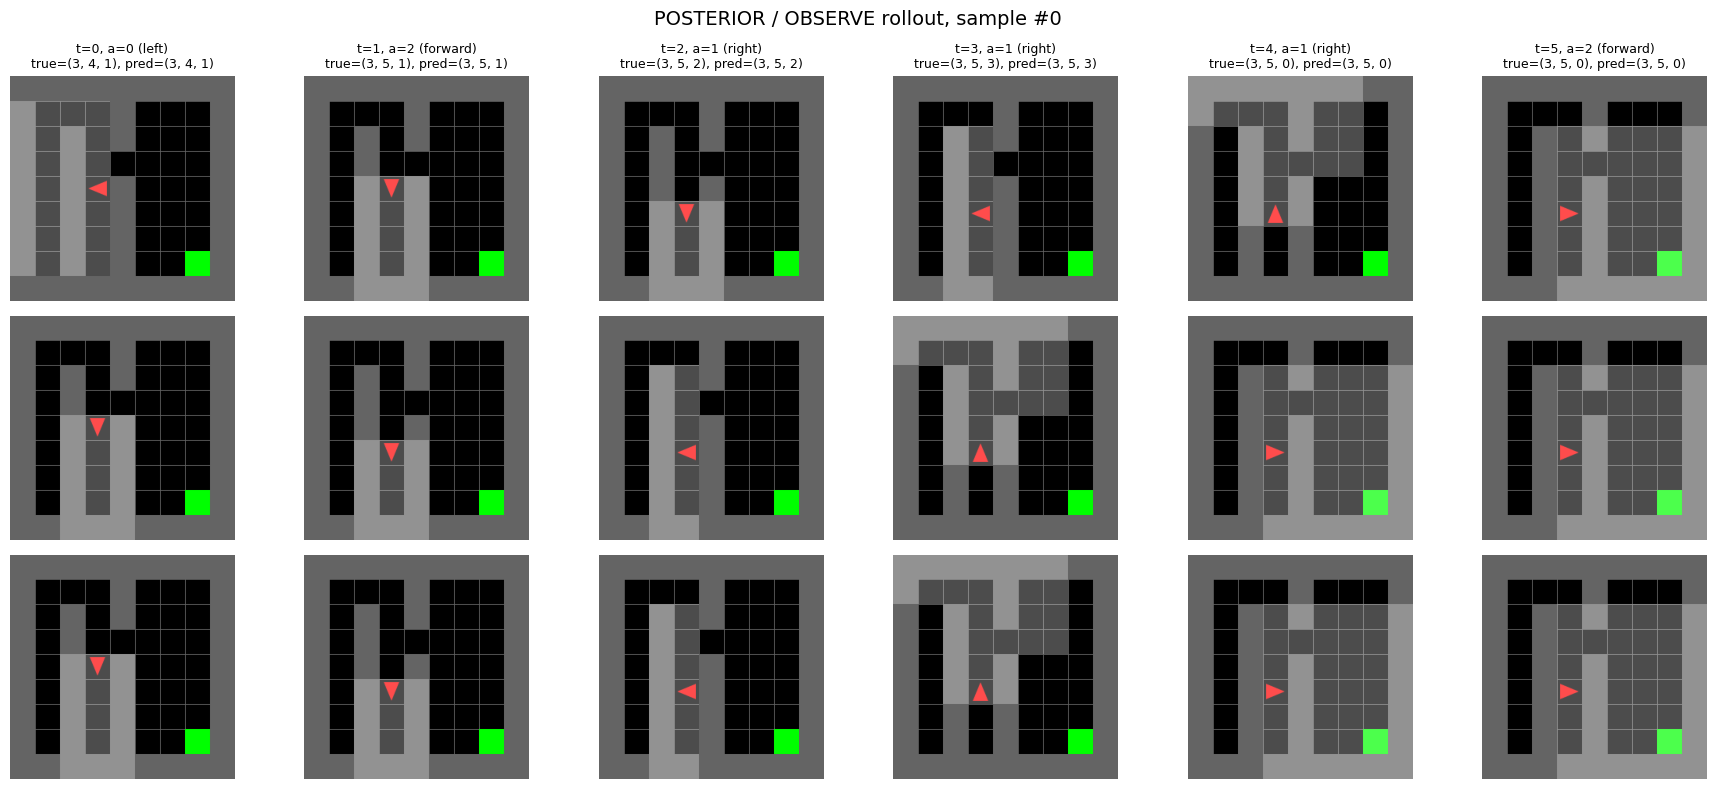

In [94]:
batch, imagine_out = plot_state_rollout_comparison(
    model=model,
    loader=viz_loader,
    device=device,
    item_idx=0,
    max_steps=6,
    use_imagine=False,
    use_predicted_maps=False,
)

IMAGINE / PRIOR rollout
pos_acc_by_t:  [1.    0.969 0.938 0.891 0.859 0.797]
full_acc_by_t: [1.    0.969 0.938 0.891 0.859 0.797]


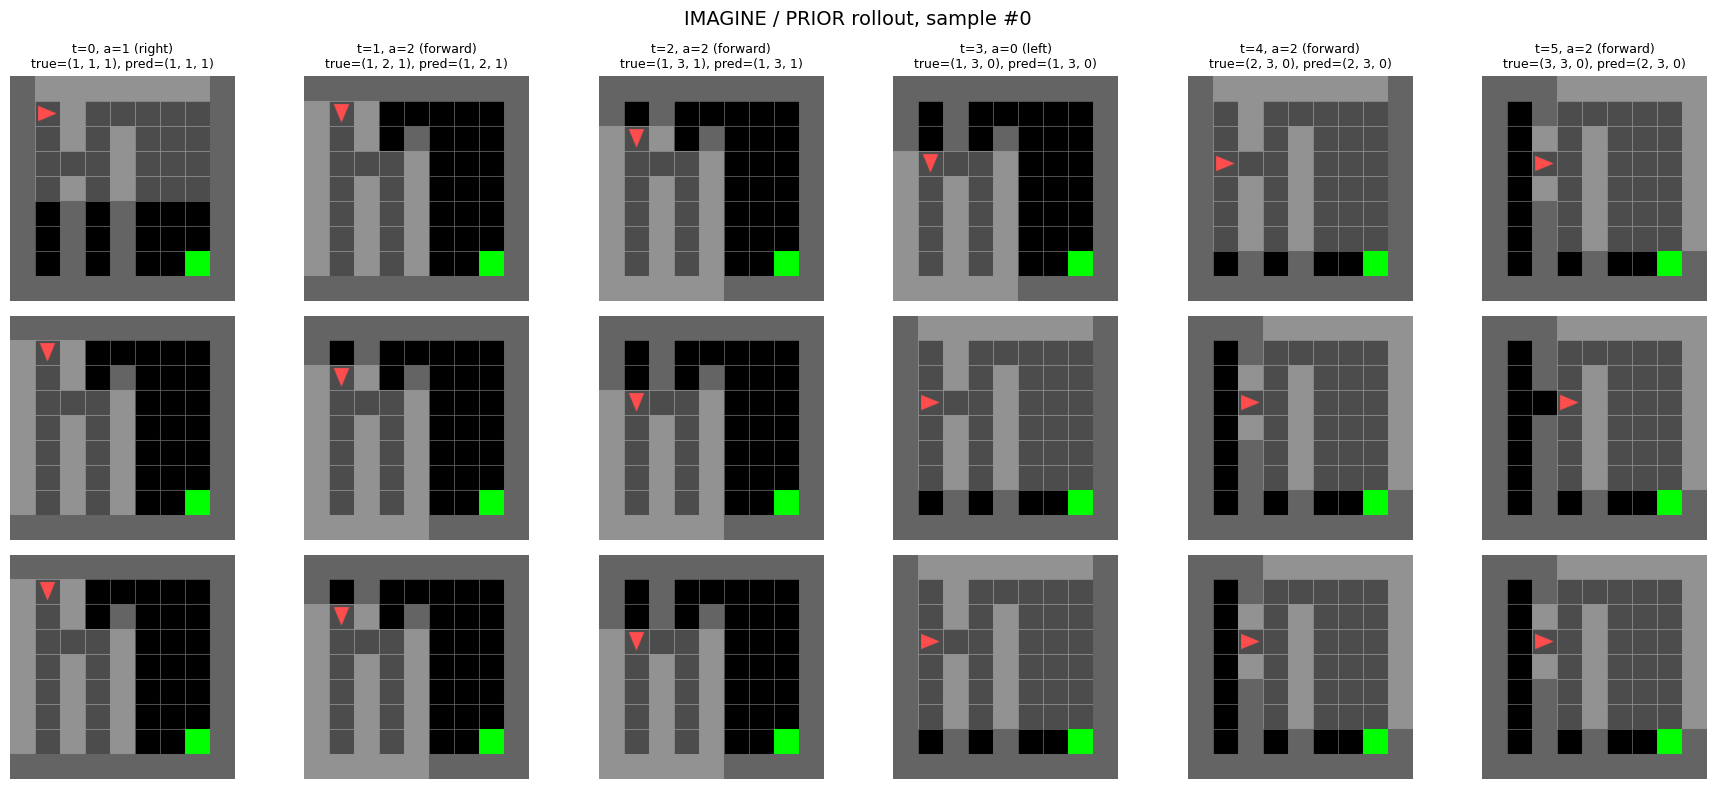

In [99]:
batch, imagine_out = plot_state_rollout_comparison(
    model=model,
    loader=viz_loader,
    device=device,
    item_idx=0,
    max_steps=6,
    use_imagine=True,
    use_predicted_maps=False,
)

## 9. Baseline 1: random policy

In [255]:
NAV_ACTIONS = [0, 1, 2]  # left, right, forward


def run_random_episode(env, rng, max_steps=None, seed=None):
    obs, info = env.reset(seed=seed)

    if max_steps is None:
        max_steps = env.unwrapped.max_steps

    total_reward = 0.0

    for step in range(1, max_steps + 1):
        action = int(rng.choice(NAV_ACTIONS))

        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += float(reward)
        done = terminated or truncated

        if done:
            break

    return {
        "success": total_reward > 0,
        "return": total_reward,
        "steps": step,
        "timeout": truncated,
    }


def evaluate_random_policy(env_name, n_episodes=100, seed=42, max_steps=None):
    rng = np.random.default_rng(seed)
    rows = []
    

    for episode in tqdm(range(n_episodes), desc="Random policy"):
        env = gym.make(env_name, render_mode="rgb_array")
        episode_seed = int(rng.integers(0, 2**22))

        result = run_random_episode(
            env=env,
            rng=rng,
            max_steps=max_steps,
            seed=episode_seed,
        )

        rows.append({
            "episode": episode,
            **result,
        })

        env.close()

    df = pd.DataFrame(rows)

    summary = pd.DataFrame([{
        "policy": "random",
        "episodes": n_episodes,
        "success_rate": df["success"].mean(),
        "mean_return": df["return"].mean(),
        "mean_steps": df["steps"].mean(),
        "timeout_rate": df["timeout"].mean(),
    }])

    return df, summary

In [256]:
# Отрисовка траектории движения агент в режиме случайного блуждания
def save_random_policy_gif(env_name, gif_path="random_policy.gif", seed=42, max_steps=80):
    rng = np.random.default_rng(seed)
    env = gym.make(env_name, render_mode="rgb_array")

    obs, info = env.reset(seed=seed)
    frames = [env.render()]

    for _ in range(max_steps):
        action = int(rng.choice(NAV_ACTIONS))
        obs, reward, terminated, truncated, info = env.step(action)

        frames.append(env.render())

        if terminated or truncated:
            break

    env.close()
    imageio.mimsave(gif_path, frames, duration=0.2)
    return gif_path

### Random policy rollout

Агент выбирает случайные действия `left`, `right`, `forward` и не использует информацию о цели (нет scorer).

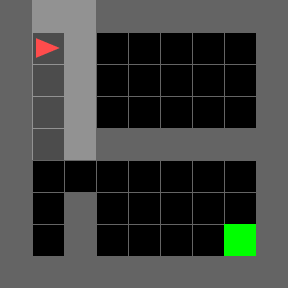

In [257]:
gif_path = save_random_policy_gif(
    env_name=ENV_NAME,
    gif_path="random_policy.gif",
    seed=random.randint(1, 2**22),
    max_steps=80,
)
display(Markdown("### Random policy rollout"))
display(Markdown(
    "Агент выбирает случайные действия `left`, `right`, `forward` и не использует информацию о цели (нет scorer)."
))
display(Image(filename=gif_path))

In [258]:
random_df, random_summary = evaluate_random_policy(
    env_name=ENV_NAME,
    n_episodes=100,
    seed=42,
)

display(random_summary)

Random policy: 100%|██████████████████████████| 100/100 [00:02<00:00, 41.46it/s]


,policy,episodes,success_rate,mean_return,mean_steps,timeout_rate
0,random,100,0.15,0.079611,300.74,0.85


## 10. Baseline 2: RSSM-MPC + distance scorer

Random-shooting planner строит imagined rollouts в world model и оценивает raw predicted states
по Manhattan distance до цели. В baseline не используются BFS, A* или точная MiniGrid-динамика.

In [ ]:
def score_raw_rssm_rollouts(
    pred_x,
    pred_y,
    pred_dir,
    actions,
    agent_x0,
    agent_y0,
    wall_map,
    goal_map,
    stuck_count=0,
    eval_horizon=10,
    gamma=0.9,
    w_progress=2.0,
    w_discounted_dist=1.0,
    w_final_dist=0.3,
    w_goal=30.0,
    w_in_wall=1.0,
    w_escape=25.0,
    w_no_escape=120.0,
):
    """
    Fair raw RSSM scorer.

    Оценивает только координаты, предсказанные world model.
    Не использует BFS, exact dynamics или symbolic transition rules.
    """
    B, H = pred_x.shape
    device = pred_x.device

    T = min(eval_horizon, H)

    pred_x_eval = pred_x[:, :T]
    pred_y_eval = pred_y[:, :T]

    goal_x, goal_y = get_goal_xy(goal_map)

    dist = (
        (pred_x_eval - goal_x[:, None]).abs()
        + (pred_y_eval - goal_y[:, None]).abs()
    ).float()

    start_dist = (
        (agent_x0 - goal_x).abs()
        + (agent_y0 - goal_y).abs()
    ).float()

    min_dist = dist.min(dim=1).values
    final_dist = dist[:, -1]
    progress = start_dist - min_dist

    discounts = gamma ** torch.arange(T, device=device).float()
    discounts = discounts / discounts.sum()

    discounted_dist = (dist * discounts[None, :]).sum(dim=1)

    goal_reached = (dist == 0).float().max(dim=1).values

    batch_idx = torch.arange(B, device=device)[:, None].expand_as(pred_x_eval)
    in_wall = wall_map[batch_idx, pred_y_eval, pred_x_eval].float().sum(dim=1)

    score = (
        w_progress * progress
        - w_discounted_dist * discounted_dist
        - w_final_dist * final_dist
        + w_goal * goal_reached
        - w_in_wall * in_wall
    )

    escaped = torch.zeros(B, device=device)
    no_escape = torch.zeros(B, device=device)
    escape_speed = torch.zeros(B, device=device)

    if stuck_count >= 2:
        K = min(3, H)

        escape_dist = (
            (pred_x[:, :K] - agent_x0[:, None]).abs()
            + (pred_y[:, :K] - agent_y0[:, None]).abs()
        ).float()

        escaped = (escape_dist.max(dim=1).values > 0).float()
        no_escape = 1.0 - escaped

        escape_weights = torch.linspace(1.0, 0.5, K, device=device)
        escape_speed = (escape_dist * escape_weights[None, :]).max(dim=1).values

        score = score + w_escape * escape_speed - w_no_escape * no_escape

    debug = {
        "score": score,
        "start_dist": start_dist,
        "min_dist": min_dist,
        "final_dist": final_dist,
        "progress": progress,
        "discounted_dist": discounted_dist,
        "goal_reached": goal_reached,
        "in_wall": in_wall,
        "escaped": escaped,
        "no_escape": no_escape,
        "escape_speed": escape_speed,
        "stuck_count": torch.full((B,), float(stuck_count), device=device),
    }

    return score, debug

In [ ]:
@torch.no_grad()
def rssm_distance_mpc_action(
    model,
    agent_x,
    agent_y,
    agent_dir,
    wall_map,
    goal_map,
    num_candidates=2048,
    horizon=10,
    device="cuda",
    stuck_count=0,
):
    model.eval()

    actions = torch.randint(
        low=0,
        high=3,
        size=(num_candidates, horizon),
        device=device,
    )

    actions[:, 0] = torch.arange(num_candidates, device=device) % 3

    agent_x0 = agent_x.repeat(num_candidates)
    agent_y0 = agent_y.repeat(num_candidates)
    agent_dir0 = agent_dir.repeat(num_candidates)

    wall_map_rep = wall_map.repeat(num_candidates, 1, 1)
    goal_map_rep = goal_map.repeat(num_candidates, 1, 1)

    out = model.imagine_rollout(
        agent_x0=agent_x0,
        agent_y0=agent_y0,
        agent_dir0=agent_dir0,
        wall_map=wall_map_rep,
        goal_map=goal_map_rep,
        actions=actions,
        sample=False,
    )

    pred_x = out["pred_x_logits"].argmax(dim=-1)
    pred_y = out["pred_y_logits"].argmax(dim=-1)
    pred_dir = out["pred_dir_logits"].argmax(dim=-1)

    score, debug = score_raw_rssm_rollouts(
        pred_x=pred_x,
        pred_y=pred_y,
        pred_dir=pred_dir,
        actions=actions,
        agent_x0=agent_x0,
        agent_y0=agent_y0,
        wall_map=wall_map_rep,
        goal_map=goal_map_rep,
        stuck_count=stuck_count,
    )

    best_idx = score.argmax()

    return {
        "action": int(actions[best_idx, 0].detach().cpu().item()),
        "sequence": actions[best_idx].detach().cpu(),
        "score": float(score[best_idx].detach().cpu().item()),
        "debug": {
            key: (
                float(value[best_idx].detach().cpu().item())
                if torch.is_tensor(value) and value.ndim == 1
                else value
            )
            for key, value in debug.items()
        },
    }

In [ ]:
def run_mpc_episode(
    model,
    device,
    seed=None,
    max_steps=None,
    num_candidates=2048,
    horizon=10,
):
    env = gym.make(ENV_NAME, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    if max_steps is None:
        max_steps = env.unwrapped.max_steps

    total_reward = 0.0
    terminated = False
    truncated = False

    prev_pos = None
    stuck_count = 0

    for step in range(1, max_steps + 1):
        agent_x, agent_y, agent_dir, wall_map, goal_map = extract_state_from_env(
            env,
            device,
        )

        curr_pos = (int(agent_x.item()), int(agent_y.item()))

        if prev_pos is not None and curr_pos == prev_pos:
            stuck_count += 1
        else:
            stuck_count = 0

        prev_pos = curr_pos

        plan = rssm_distance_mpc_action(
            model=model,
            agent_x=agent_x,
            agent_y=agent_y,
            agent_dir=agent_dir,
            wall_map=wall_map,
            goal_map=goal_map,
            num_candidates=num_candidates,
            horizon=horizon,
            device=device,
            stuck_count=stuck_count,
        )

        action = plan["action"]
        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += float(reward)

        if terminated or truncated:
            break

    env.close()

    return {
        "success": total_reward > 0,
        "return": total_reward,
        "steps": step,
        "timeout": bool(truncated or (step == max_steps and total_reward == 0)),
    }

In [287]:
def evaluate_mpc_policy(
    model,
    device,
    n_episodes=100,
    seed=42,
    num_candidates=2048,
    horizon=10,
):
    rng = np.random.default_rng(seed)
    rows = []

    model.eval()

    for episode in tqdm(range(n_episodes), desc="RSSM-MPC"):
        episode_seed = int(rng.integers(0, 2**31 - 1))

        result = run_mpc_episode(
            model=model,
            device=device,
            seed=episode_seed,
            num_candidates=num_candidates,
            horizon=horizon,
        )

        rows.append({
            "episode": episode,
            **result,
        })

    df = pd.DataFrame(rows)

    summary = pd.DataFrame([{
        "policy": "rssm_distance_mpc_raw",
        "episodes": n_episodes,
        "success_rate": df["success"].mean(),
        "mean_return": df["return"].mean(),
        "mean_steps": df["steps"].mean(),
        "timeout_rate": df["timeout"].mean(),
    }])

    return df, summary

In [288]:
ACTION_NAMES = {
    0: "left",
    1: "right",
    2: "forward",
}


def save_mpc_policy_gif(
    env_name,
    model,
    device,
    gif_path="rssm_distance_mpc_raw.gif",
    seed=42,
    max_steps=80,
    num_candidates=512,
    horizon=10,
    duration=0.2,
):
    env = gym.make(env_name, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    frames = [env.render()]
    actions = []
    total_reward = 0.0

    prev_pos = None
    stuck_count = 0

    model.eval()

    for step in range(1, max_steps + 1):
        agent_x, agent_y, agent_dir, wall_map, goal_map = extract_state_from_env(
            env,
            device,
        )

        curr_pos = (int(agent_x.item()), int(agent_y.item()))

        if prev_pos is not None and curr_pos == prev_pos:
            stuck_count += 1
        else:
            stuck_count = 0

        prev_pos = curr_pos

        plan = rssm_distance_mpc_action(
            model=model,
            agent_x=agent_x,
            agent_y=agent_y,
            agent_dir=agent_dir,
            wall_map=wall_map,
            goal_map=goal_map,
            num_candidates=num_candidates,
            horizon=horizon,
            device=device,
            stuck_count=stuck_count,
        )

        action = int(plan["action"])
        actions.append(action)

        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)

        frames.append(env.render())

        if terminated or truncated:
            break

    env.close()

    imageio.mimsave(gif_path, frames, duration=duration)

    return {
        "gif_path": gif_path,
        "success": total_reward > 0,
        "return": total_reward,
        "steps": len(actions),
        "actions": actions,
        "action_names": [ACTION_NAMES[a] for a in actions],
    }

### RSSM-MPC rollout with raw distance-based scorer

Агент генерирует candidate action sequences, строит imagined rollouts через RSSM world model и выбирает первое действие из траектории с лучшим raw distance-based score. Используется только простой anti-stuck сигнал по реальной истории координат.

success=True, return=0.847, steps=55


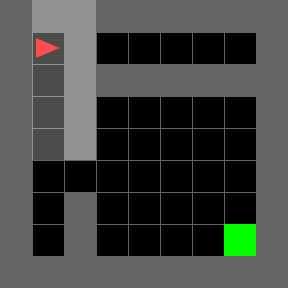

In [294]:
mpc_gif_result = save_mpc_policy_gif(
    env_name=ENV_NAME,
    model=model,
    device=device,
    gif_path="rssm_distance_mpc_raw.gif",
    seed=random.randint(1, 2**22),
    max_steps=80,
    num_candidates=512,
    horizon=10,
)

display(Markdown("### RSSM-MPC rollout with raw distance-based scorer"))
display(Markdown(
    "Агент генерирует candidate action sequences, строит imagined rollouts через RSSM world model "
    "и выбирает первое действие из траектории с лучшим raw distance-based score. "
    "Используется только простой anti-stuck сигнал по реальной истории координат."
))

print(
    f"success={mpc_gif_result['success']}, "
    f"return={mpc_gif_result['return']:.3f}, "
    f"steps={mpc_gif_result['steps']}"
)

display(Image(filename=mpc_gif_result["gif_path"]))

In [299]:
mpc_df, mpc_summary = evaluate_mpc_policy(
    model=model,
    device=device,
    n_episodes=100,
    seed=42,
    num_candidates=2048,
    horizon=15,
)

display(mpc_summary)

RSSM-MPC: 100%|███████████████████████████████| 100/100 [08:54<00:00,  5.35s/it]


,policy,episodes,success_rate,mean_return,mean_steps,timeout_rate
0,rssm_distance_mpc_raw,100,0.37,0.304583,227.67,0.63


## 11. RSSM-MPC + cached CLIP scorer

CLIP применяется к imagined future states из RSSM rollout. Чтобы MPC не рендерил и не скорил CLIP
для каждого candidate заново, в начале эпизода строится таблица `clip_score_table[y, x, dir]` для
всех возможных состояний маленькой MiniGrid-карты.

In [77]:
from PIL import Image as PILImage
from transformers import CLIPModel, CLIPProcessor


NAV_ACTIONS = [
    Actions.left.value,
    Actions.right.value,
    Actions.forward.value,
]

ACTION_NAMES = {
    Actions.left.value: "left",
    Actions.right.value: "right",
    Actions.forward.value: "forward",
}


def get_goal_xy(goal_map):
    B, H, W = goal_map.shape
    flat_idx = goal_map.reshape(B, -1).argmax(dim=1)
    goal_y = flat_idx // W
    goal_x = flat_idx % W

    return goal_x.long(), goal_y.long()


def extract_state_from_env(env, device):
    x, y = env.unwrapped.agent_pos
    d = env.unwrapped.agent_dir

    grid = env.unwrapped.grid
    W, H = grid.width, grid.height

    wall_map = np.zeros((H, W), dtype=np.float32)
    goal_map = np.zeros((H, W), dtype=np.float32)

    for xx in range(W):
        for yy in range(H):
            obj = grid.get(xx, yy)

            if obj is None:
                continue

            if obj.type == "wall":
                wall_map[yy, xx] = 1.0
            elif obj.type == "goal":
                goal_map[yy, xx] = 1.0

    return (
        torch.tensor([x], device=device).long(),
        torch.tensor([y], device=device).long(),
        torch.tensor([d], device=device).long(),
        torch.tensor(wall_map, device=device).unsqueeze(0),
        torch.tensor(goal_map, device=device).unsqueeze(0),
    )


def find_latest_state_world_model_path(project_dir=PROJECT_DIR):
    candidates = []

    if os.path.exists(STATE_MODEL_PATH):
        candidates.append(STATE_MODEL_PATH)

    for name in os.listdir(project_dir):
        if name.endswith(".pt") and "state" in name and "world_model" in name:
            candidates.append(os.path.join(project_dir, name))

    candidates = sorted(set(candidates))

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No saved state world model found in {project_dir}. "
            f"Expected at least {STATE_MODEL_PATH}"
        )

    return max(candidates, key=os.path.getmtime)


def load_latest_state_world_model_for_clip(device=device):
    model_path = find_latest_state_world_model_path(PROJECT_DIR)

    loaded_model = StateWorldModel(
        num_actions=3,
        width=9,
        height=9,
        action_dim=8,
        obs_dim=128,
        deter_dim=128,
        stoch_dim=64,
        hidden_dim=256,
    )

    state_dict = torch.load(model_path, map_location="cpu")
    loaded_model.load_state_dict(state_dict)
    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    print(f"Loaded latest state world model: {model_path}")
    return loaded_model, model_path


clip_world_model, clip_world_model_path = load_latest_state_world_model_for_clip(device=device)

CLIP_MODEL_NAME = "openai/clip-vit-base-patch16"
clip_device = torch.device(device) if isinstance(device, str) else device

clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(clip_device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model.eval()

for param in clip_model.parameters():
    param.requires_grad_(False)

print(f"Loaded CLIP model: {CLIP_MODEL_NAME}")
print(f"CLIP device: {clip_device}")


Loaded latest state world model: /Users/roman666/Documents/Tbank/state_rssm_world_model_best.pt


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded CLIP model: openai/clip-vit-base-patch16
CLIP device: mps


In [78]:
POSITIVE_PROMPTS = [
    "top down gridworld, red triangle on green goal tile",
    "MiniGrid image, red agent on the green goal",
    "red triangular agent located at the green square",
    "the red agent is at the green goal tile",
]

NEGATIVE_PROMPTS = [
    "top down gridworld, red triangle not on green goal tile",
    "MiniGrid image, red agent away from the green goal",
    "red triangular agent located far from the green square",
    "the red agent is not at the green goal tile",
]


def _clip_output_to_tensor(output, kind):
    """
    Different transformers versions may return either a tensor or a model output
    dataclass from get_text_features / get_image_features.
    """
    if torch.is_tensor(output):
        return output

    preferred_attrs = (
        ["text_embeds", "pooler_output", "last_hidden_state"]
        if kind == "text"
        else ["image_embeds", "pooler_output", "last_hidden_state"]
    )

    for attr in preferred_attrs:
        if hasattr(output, attr):
            value = getattr(output, attr)

            if torch.is_tensor(value):
                if attr == "last_hidden_state" and value.ndim == 3:
                    return value[:, 0]

                return value

    if isinstance(output, (tuple, list)):
        for value in output:
            if torch.is_tensor(value):
                if value.ndim == 3:
                    return value[:, 0]

                return value

    raise TypeError(f"Unexpected CLIP {kind} output type: {type(output)}")


@torch.no_grad()
def build_clip_text_bank(
    clip_model,
    clip_processor,
    positive_prompts,
    negative_prompts,
    device,
):
    prompts = positive_prompts + negative_prompts

    inputs = clip_processor(
        text=prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    text_features = clip_model.get_text_features(**inputs)
    text_features = _clip_output_to_tensor(text_features, kind="text")
    text_features = F.normalize(text_features, dim=-1)

    n_pos = len(positive_prompts)

    return {
        "positive": text_features[:n_pos],
        "negative": text_features[n_pos:],
        "positive_prompts": positive_prompts,
        "negative_prompts": negative_prompts,
    }


def to_pil_rgb(image):
    if isinstance(image, PILImage.Image):
        return image.convert("RGB")

    if torch.is_tensor(image):
        image = image.detach().cpu().numpy()

    image = np.asarray(image)

    if image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = image * 255
        image = np.clip(image, 0, 255).astype(np.uint8)

    return PILImage.fromarray(image).convert("RGB")


@torch.no_grad()
def score_images_with_clip(
    images,
    clip_model,
    clip_processor,
    text_bank,
    device,
    batch_size=128,
):
    if isinstance(images, (PILImage.Image, np.ndarray)) or torch.is_tensor(images):
        images = [images]

    images = [to_pil_rgb(img) for img in images]
    all_scores = []

    for start in range(0, len(images), batch_size):
        chunk = images[start:start + batch_size]

        inputs = clip_processor(
            images=chunk,
            return_tensors="pt",
        ).to(device)

        image_features = clip_model.get_image_features(**inputs)
        image_features = _clip_output_to_tensor(image_features, kind="image")
        image_features = F.normalize(image_features, dim=-1)

        positive_scores = image_features @ text_bank["positive"].T
        negative_scores = image_features @ text_bank["negative"].T

        scores = positive_scores.mean(dim=1) - negative_scores.max(dim=1).values
        all_scores.append(scores.detach().cpu())

    return torch.cat(all_scores, dim=0)


clip_text_bank = build_clip_text_bank(
    clip_model=clip_model,
    clip_processor=clip_processor,
    positive_prompts=POSITIVE_PROMPTS,
    negative_prompts=NEGATIVE_PROMPTS,
    device=clip_device,
)

print("Positive prompts:", len(clip_text_bank["positive_prompts"]))
print("Negative prompts:", len(clip_text_bank["negative_prompts"]))
print("Text embedding dim:", clip_text_bank["positive"].shape[-1])


Positive prompts: 4
Negative prompts: 4
Text embedding dim: 512


In [79]:
def render_state_with_minigrid(
    render_env,
    agent_x,
    agent_y,
    agent_dir,
    wall_map,
    goal_map,
):
    if torch.is_tensor(wall_map):
        wall_map = wall_map.detach().cpu().numpy()

    if torch.is_tensor(goal_map):
        goal_map = goal_map.detach().cpu().numpy()

    if wall_map.ndim == 3:
        wall_map = wall_map[0]

    if goal_map.ndim == 3:
        goal_map = goal_map[0]

    height, width = wall_map.shape
    grid = Grid(width, height)

    for y in range(height):
        for x in range(width):
            if wall_map[y, x] > 0.5:
                grid.set(x, y, Wall())
            elif goal_map[y, x] > 0.5:
                grid.set(x, y, Goal())

    env_u = render_env.unwrapped
    env_u.grid = grid
    env_u.agent_pos = np.array([int(agent_x), int(agent_y)])
    env_u.agent_dir = int(agent_dir)
    env_u.carrying = None

    return render_env.render()


_clip_score_table_cache = {}


def clip_score_table_cache_key(wall_map, goal_map):
    if torch.is_tensor(wall_map):
        wall_map = wall_map.detach().cpu().numpy()

    if torch.is_tensor(goal_map):
        goal_map = goal_map.detach().cpu().numpy()

    if wall_map.ndim == 3:
        wall_map = wall_map[0]

    if goal_map.ndim == 3:
        goal_map = goal_map[0]

    wall_u8 = (wall_map > 0.5).astype(np.uint8)
    goal_u8 = (goal_map > 0.5).astype(np.uint8)

    return (
        wall_u8.shape,
        wall_u8.tobytes(),
        goal_u8.tobytes(),
        CLIP_MODEL_NAME,
        tuple(POSITIVE_PROMPTS),
        tuple(NEGATIVE_PROMPTS),
    )


@torch.no_grad()
def build_clip_state_score_table(
    wall_map,
    goal_map,
    clip_model,
    clip_processor,
    clip_text_bank,
    clip_device,
    table_device,
    env_name=ENV_NAME,
    batch_size=128,
):
    """
    Строит CLIP score lookup table для всех возможных (x, y, dir).

    Для 9x9 MiniGrid это всего 9 * 9 * 4 = 324 картинки на карту.
    Дальше MPC делает только быстрый tensor lookup по raw RSSM predictions.
    """
    key = clip_score_table_cache_key(wall_map, goal_map)

    if key in _clip_score_table_cache:
        return _clip_score_table_cache[key].to(table_device)

    if torch.is_tensor(wall_map):
        wall_np = wall_map.detach().cpu().numpy()
    else:
        wall_np = np.asarray(wall_map)

    if torch.is_tensor(goal_map):
        goal_np = goal_map.detach().cpu().numpy()
    else:
        goal_np = np.asarray(goal_map)

    if wall_np.ndim == 3:
        wall_np = wall_np[0]

    if goal_np.ndim == 3:
        goal_np = goal_np[0]

    height, width = wall_np.shape
    images = []
    states = []

    render_env = gym.make(env_name, render_mode="rgb_array")
    render_env.reset(seed=0)

    for y in range(height):
        for x in range(width):
            for direction in range(4):
                image = render_state_with_minigrid(
                    render_env=render_env,
                    agent_x=x,
                    agent_y=y,
                    agent_dir=direction,
                    wall_map=wall_np,
                    goal_map=goal_np,
                )
                images.append(image)
                states.append((x, y, direction))

    render_env.close()

    scores = score_images_with_clip(
        images=images,
        clip_model=clip_model,
        clip_processor=clip_processor,
        text_bank=clip_text_bank,
        device=clip_device,
        batch_size=batch_size,
    )

    table = torch.empty(height, width, 4, dtype=torch.float32)

    for (x, y, direction), score in zip(states, scores):
        table[y, x, direction] = float(score.item())

    _clip_score_table_cache[key] = table.cpu()

    return table.to(table_device)


In [80]:
def make_clip_xy_score_table(clip_score_table, wall_map):
    """
    clip_score_table: [H, W, 4] -> [H, W]

    Усредняем CLIP-score по направлениям, чтобы агент не крутился на месте
    ради чуть лучшего ракурса.
    """
    wall = wall_map.detach()

    if wall.ndim == 3:
        wall = wall[0]

    wall = wall.to(clip_score_table.device) > 0.5
    free = ~wall

    table = clip_score_table.clone()
    table[wall] = table[free].min() - 10.0

    xy_score = table.mean(dim=-1)
    xy_score = (xy_score - xy_score[free].mean()) / xy_score[free].std().clamp_min(1e-6)
    xy_score[wall] = -10.0

    return xy_score


@torch.no_grad()
def score_clip_rollouts_cached(
    pred_x,
    pred_y,
    clip_xy_score_table,
    goal_map,
    agent_x0,
    agent_y0,
    stuck_count=0,
    eval_horizon=10,
):
    """
    Простой scorer:
        CLIP-xy landscape
        + raw Manhattan progress по RSSM-predicted координатам
        + anti-stuck по raw predicted координатам
    """
    B, H = pred_x.shape
    device = pred_x.device

    T = min(H, eval_horizon)
    table_h, table_w = clip_xy_score_table.shape

    xs = pred_x[:, :T].clamp(0, table_w - 1)
    ys = pred_y[:, :T].clamp(0, table_h - 1)

    clip_t = clip_xy_score_table[ys, xs]
    clip_score = 0.7 * clip_t.max(dim=1).values + 0.3 * clip_t[:, -1]

    goal_x, goal_y = get_goal_xy(goal_map)
    dist = (
        (xs - goal_x[:, None]).abs()
        + (ys - goal_y[:, None]).abs()
    ).float()

    start_dist = (
        (agent_x0 - goal_x).abs()
        + (agent_y0 - goal_y).abs()
    ).float()

    progress = start_dist - dist.min(dim=1).values
    final_dist = dist[:, -1]
    goal_reached = (dist == 0).float().max(dim=1).values

    score = (
        clip_score
        + 0.8 * progress
        - 0.25 * final_dist
        + 8.0 * goal_reached
    )

    escaped = torch.zeros(B, device=device)
    no_escape = torch.zeros(B, device=device)

    if stuck_count >= 2:
        K = min(3, T)

        move_dist = (
            (xs[:, :K] - agent_x0[:, None]).abs()
            + (ys[:, :K] - agent_y0[:, None]).abs()
        ).float()

        max_move = move_dist.max(dim=1).values
        escaped = (max_move > 0).float()
        no_escape = 1.0 - escaped

        score = score + 2.0 * max_move - 8.0 * no_escape

    debug = {
        "score": score,
        "clip_score": clip_score,
        "progress": progress,
        "final_dist": final_dist,
        "goal_reached": goal_reached,
        "escaped": escaped,
        "no_escape": no_escape,
        "stuck_count": torch.full((B,), float(stuck_count), device=device),
    }

    return score, debug


### CLIP heatmap для cached scorer

Перед запуском MPC посмотрим, как CLIP оценивает клетки карты. Таблица строится один раз для всех
`(x, y, dir)`, затем усредняется по направлениям в `(x, y)` heatmap.

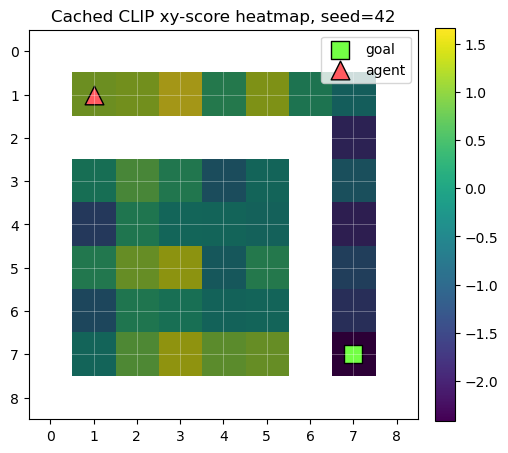

In [81]:
@torch.no_grad()
def show_clip_xy_heatmap(seed=42, clip_batch_size=128):
    env = gym.make(ENV_NAME, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    agent_x, agent_y, agent_dir, wall_map, goal_map = extract_state_from_env(env, device)

    clip_score_table = build_clip_state_score_table(
        wall_map=wall_map,
        goal_map=goal_map,
        clip_model=clip_model,
        clip_processor=clip_processor,
        clip_text_bank=clip_text_bank,
        clip_device=clip_device,
        table_device=device,
        batch_size=clip_batch_size,
    )

    clip_xy_score = make_clip_xy_score_table(clip_score_table, wall_map)

    score_img = clip_xy_score.detach().cpu().numpy()
    wall_img = wall_map[0].detach().cpu().numpy() > 0.5

    goal_x, goal_y = get_goal_xy(goal_map)
    goal_x, goal_y = int(goal_x.item()), int(goal_y.item())
    agent_x, agent_y = int(agent_x.item()), int(agent_y.item())

    masked_score = np.ma.masked_where(wall_img, score_img)

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    im = ax.imshow(masked_score, cmap="viridis")
    ax.imshow(wall_img, cmap="gray", alpha=0.35)

    ax.scatter(goal_x, goal_y, s=180, marker="s", c="#73ff45", edgecolors="black", label="goal")
    ax.scatter(agent_x, agent_y, s=180, marker="^", c="#ff5a5f", edgecolors="black", label="agent")

    ax.set_title(f"Cached CLIP xy-score heatmap, seed={seed}")
    ax.set_xticks(range(score_img.shape[1]))
    ax.set_yticks(range(score_img.shape[0]))
    ax.grid(color="white", linewidth=0.6, alpha=0.35)
    ax.legend(loc="upper right")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

    env.close()


show_clip_xy_heatmap(seed=42)

In [82]:
@torch.no_grad()
def rssm_clip_mpc_action(
    model,
    agent_x,
    agent_y,
    agent_dir,
    wall_map,
    goal_map,
    clip_xy_score_table,
    num_candidates=512,
    horizon=10,
    stuck_count=0,
    device="cuda",
):
    model.eval()

    actions = torch.randint(
        low=0,
        high=len(NAV_ACTIONS),
        size=(num_candidates, horizon),
        device=device,
    )
    actions[:, 0] = torch.arange(num_candidates, device=device) % len(NAV_ACTIONS)

    agent_x0 = agent_x.repeat(num_candidates)
    agent_y0 = agent_y.repeat(num_candidates)
    agent_dir0 = agent_dir.repeat(num_candidates)

    wall_map_rep = wall_map.repeat(num_candidates, 1, 1)
    goal_map_rep = goal_map.repeat(num_candidates, 1, 1)

    out = model.imagine_rollout(
        agent_x0=agent_x0,
        agent_y0=agent_y0,
        agent_dir0=agent_dir0,
        wall_map=wall_map_rep,
        goal_map=goal_map_rep,
        actions=actions,
        sample=False,
    )

    pred_x = out["pred_x_logits"].argmax(dim=-1)
    pred_y = out["pred_y_logits"].argmax(dim=-1)

    score, debug = score_clip_rollouts_cached(
        pred_x=pred_x,
        pred_y=pred_y,
        clip_xy_score_table=clip_xy_score_table,
        goal_map=goal_map_rep,
        agent_x0=agent_x0,
        agent_y0=agent_y0,
        stuck_count=stuck_count,
        eval_horizon=horizon,
    )

    best_idx = score.argmax()

    return {
        "action": int(actions[best_idx, 0].detach().cpu().item()),
        "sequence": actions[best_idx].detach().cpu(),
        "score": float(score[best_idx].detach().cpu().item()),
        "debug": {
            key: (
                float(value[best_idx].detach().cpu().item())
                if torch.is_tensor(value) and value.ndim == 1
                else value
            )
            for key, value in debug.items()
        },
    }


In [83]:
def run_clip_mpc_episode(
    model,
    device,
    seed=None,
    max_steps=None,
    num_candidates=512,
    horizon=10,
    record=False,
    clip_batch_size=128,
):
    env = gym.make(ENV_NAME, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    if max_steps is None:
        max_steps = env.unwrapped.max_steps

    frames = []
    actions_taken = []
    scores = []

    if record:
        frames.append(env.render())

    total_reward = 0.0
    terminated = False
    truncated = False
    prev_pos = None
    stuck_count = 0
    pending_actions = []

    agent_x, agent_y, agent_dir, wall_map, goal_map = extract_state_from_env(env, device)

    clip_score_table = build_clip_state_score_table(
        wall_map=wall_map,
        goal_map=goal_map,
        clip_model=clip_model,
        clip_processor=clip_processor,
        clip_text_bank=clip_text_bank,
        clip_device=clip_device,
        table_device=device,
        batch_size=clip_batch_size,
    )
    clip_xy_score_table = make_clip_xy_score_table(clip_score_table, wall_map)

    for step in range(1, max_steps + 1):
        agent_x, agent_y, agent_dir, wall_map, goal_map = extract_state_from_env(env, device)

        curr_pos = (int(agent_x.item()), int(agent_y.item()))

        if prev_pos is not None and curr_pos == prev_pos:
            stuck_count += 1
        else:
            stuck_count = 0

        prev_pos = curr_pos

        if stuck_count == 0:
            pending_actions = []

        if pending_actions and stuck_count > 0:
            action = int(pending_actions.pop(0))
            score = float("nan")
        else:
            mpc_out = rssm_clip_mpc_action(
                model=model,
                agent_x=agent_x,
                agent_y=agent_y,
                agent_dir=agent_dir,
                wall_map=wall_map,
                goal_map=goal_map,
                clip_xy_score_table=clip_xy_score_table,
                num_candidates=num_candidates,
                horizon=horizon,
                stuck_count=stuck_count,
                device=device,
            )

            action = int(mpc_out["action"])
            score = mpc_out["score"]

            if stuck_count >= 2:
                pending_actions = [
                    int(a)
                    for a in mpc_out["sequence"][1:3].tolist()
                ]

        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += float(reward)
        actions_taken.append(action)
        scores.append(score)

        if record:
            frames.append(env.render())

        if terminated or truncated:
            break

    env.close()

    return {
        "seed": seed,
        "success": total_reward > 0,
        "return": total_reward,
        "steps": step,
        "timeout": bool(truncated or (step == max_steps and total_reward == 0)),
        "actions": actions_taken,
        "action_names": [ACTION_NAMES[a] for a in actions_taken],
        "scores": scores,
        "frames": frames,
    }


def evaluate_clip_mpc_policy(
    model,
    device,
    n_episodes=100,
    seed=42,
    num_candidates=512,
    horizon=10,
    max_steps=None,
    clip_batch_size=128,
):
    rng = np.random.default_rng(seed)
    rows = []

    model.eval()

    for episode in tqdm(range(n_episodes), desc="RSSM-CLIP-MPC"):
        episode_seed = int(rng.integers(0, 2**31 - 1))

        result = run_clip_mpc_episode(
            model=model,
            device=device,
            seed=episode_seed,
            max_steps=max_steps,
            num_candidates=num_candidates,
            horizon=horizon,
            record=False,
            clip_batch_size=clip_batch_size,
        )

        rows.append({
            "episode": episode,
            "seed": episode_seed,
            "success": result["success"],
            "return": result["return"],
            "steps": result["steps"],
            "timeout": result["timeout"],
        })

    df = pd.DataFrame(rows)

    summary = pd.DataFrame([{
        "policy": "rssm_clip_mpc_xy_progress_commit",
        "episodes": n_episodes,
        "success_rate": df["success"].mean(),
        "mean_return": df["return"].mean(),
        "mean_steps": df["steps"].mean(),
        "timeout_rate": df["timeout"].mean(),
        "num_candidates": num_candidates,
        "horizon": horizon,
    }])

    return df, summary


def save_clip_mpc_policy_gif(
    env_name,
    model,
    device,
    gif_path="rssm_clip_mpc.gif",
    seed=42,
    max_steps=80,
    num_candidates=512,
    horizon=10,
    duration=0.2,
    clip_batch_size=128,
):
    result = run_clip_mpc_episode(
        model=model,
        device=device,
        seed=seed,
        max_steps=max_steps,
        num_candidates=num_candidates,
        horizon=horizon,
        record=True,
        clip_batch_size=clip_batch_size,
    )

    imageio.mimsave(gif_path, result["frames"], duration=duration)
    result["gif_path"] = gif_path

    return result


seed: 1872428


### RSSM-MPC rollout with cached CLIP scorer

Агент строит imagined rollouts через RSSM world model. CLIP score один раз сворачивается в `(x, y)` таблицу, а scorer добавляет простой raw-distance progress, а при застревании агент коротко исполняет хвост выбранного RSSM-плана, чтобы не перепланировать поворот бесконечно.

success=True, return=0.936, steps=23
first actions: ['right', 'forward', 'forward', 'forward', 'forward', 'forward', 'left', 'forward', 'forward', 'forward', 'forward', 'left', 'forward', 'left', 'left', 'forward', 'forward', 'forward', 'left', 'forward']


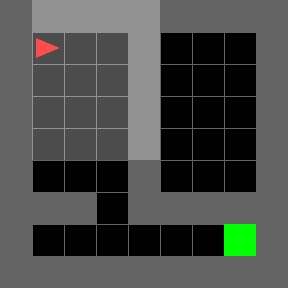

In [89]:
clip_gif_seed = random.randint(1, 2**22)

clip_gif_result = save_clip_mpc_policy_gif(
    env_name=ENV_NAME,
    model=clip_world_model,
    device=device,
    gif_path="rssm_clip_mpc.gif",
    seed=clip_gif_seed,
    max_steps=80,
    num_candidates=512,
    horizon=10,
    clip_batch_size=128,
)

print("seed:", clip_gif_seed)
display(Markdown("### RSSM-MPC rollout with cached CLIP scorer"))
display(Markdown(
    "Агент строит imagined rollouts через RSSM world model. "
    "CLIP score один раз сворачивается в `(x, y)` таблицу, а scorer добавляет простой raw-distance progress, "
    "а при застревании агент коротко исполняет хвост выбранного RSSM-плана, чтобы не перепланировать поворот бесконечно."
))

print(
    f"success={clip_gif_result['success']}, "
    f"return={clip_gif_result['return']:.3f}, "
    f"steps={clip_gif_result['steps']}"
)
print("first actions:", clip_gif_result["action_names"][:20])

display(Image(filename=clip_gif_result["gif_path"]))


In [ ]:
clip_mpc_df, clip_mpc_summary = evaluate_clip_mpc_policy(
    model=clip_world_model,
    device=device,
    n_episodes=100,
    seed=42,
    num_candidates=1024,
    horizon=15,
    clip_batch_size=128,
)

display(clip_mpc_summary)


RSSM-CLIP-MPC:  54%|██████████████▌            | 54/100 [01:44<01:25,  1.86s/it]